# 🧠 Customer Churn Prediction using Machine Learning

## 📌 Project Overview
Customer churn refers to when customers stop doing business with a company.  
In this project, we aim to **predict whether a customer will churn or stay** based on various features like contract type, monthly charges, and tenure.  
By building this model, telecom companies can **identify customers at risk of leaving** and take proactive retention actions.

---

## 🎯 Objectives
- Understand customer behavior and churn patterns through **Exploratory Data Analysis (EDA)**.  
- Build and evaluate **Machine Learning models** to predict customer churn.  
- Deploy a simple **interactive web app** for real-time predictions.  

---

## 🧩 Dataset Information
**Dataset Name:** Telco Customer Churn  
**Source:** [Kaggle - Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)  
**Target Variable:** `Churn` (Yes/No)  

**Key Features:**
- `gender`, `SeniorCitizen`, `Partner`, `Dependents`
- `tenure`, `Contract`, `MonthlyCharges`, `TotalCharges`
- `InternetService`, `PaymentMethod`, etc.

---

## 🛠️ Tech Stack
- **Programming Language:** Python  
- **Libraries:** Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn  
- **Deployment (later):** Streamlit  

---

## 📅 Project Roadmap
1. Problem Understanding & Dataset Loading  
2. Exploratory Data Analysis (EDA)  
3. Data Preprocessing  
4. Model Building & Evaluation  
5. Hyperparameter Tuning  
6. Model Deployment (Streamlit)
7. Backend (Fast-API)

---

## 👨‍💻 Anas
**Anas Shaikh**  
*Data Science Enthusiast | Machine Learning Learner*  
🔗 [GitHub Profile](https://github.com/yourusername)

---


<h2><mark>Importing Libraries</h2></mark>
Step :1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


For Model Building:

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

For Ignoring warnings

In [3]:
import warnings 
warnings.filterwarnings('ignore')

Step :2 
Load Dataset

In [4]:
df = pd.read_csv("data set/WA_Fn-UseC_-Telco-Customer-Churn.csv")

## 📊 Step 1: Data Understanding

In this section, we will:
- Explore the data shape, column types, and sample values  
- Identify which features are numerical or categorical  
- Check for missing values or incorrect data types  

We'll also make initial observations that will guide our **EDA** and **preprocessing** steps later.


In [5]:
# Checking the shape of the data set
print("Numbers of Rows",df.shape[0])
print("Numbers of Colmns",df.shape[1])

Numbers of Rows 7043
Numbers of Colmns 21


In [6]:
df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [7]:
# Statistics of our data set - only works on numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#### Observation ( from df.info() we got )

    1.Total Rows = 7043
    2.Total Columns = 21
    3.Target column = churn(object → "Yes"/"No") → whether a customer left or stayed
    4.Most columns are categorical(object type)
    5.One column stands out:
        ` TotalCharges` → it should be numeric but it stored as a object(mix types of data-type ex(string,float,int))
        
    

Conver `TotalCharges` to numeric

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'] , errors = 'coerce')

Here’s what happens step by step:

1. `pd.to_numeric()`  
Converts a column (or series) into numeric type (int or float).  
Normally, if the column contains something that cannot be converted to a number (like a blank string, text, or special character), pandas will raise an error.  

2.`errors='coerce'`
Tells pandas:  
“If a value cannot be converted to a number, set it as NaN instead of crashing.”  
This is helpful because we can then detect and handle these invalid/missing values easily.

* Check for Missing values

In [10]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

`Ah  TotalCharges has 11 Null values

* We will drop the missing values

In [90]:
df = df.dropna(subset=['TotalCharges'])

In [91]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

* making safety step to check the totalCharges column is as type numeric or not

In [14]:
df['TotalCharges'] = df['TotalCharges'].astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

### 👏 Great 
***Now***  I've converted `TotalCharges` column from *****object***** type to ****numeric****

🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱

## 🧩 Step 2: Encoding Categorical Variables

🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱



Machine learning models can only understand **numerical data** — they cannot directly interpret text or category labels like `"Male"`, `"Yes"`, `"Fiber optic"`, etc.  
Therefore, we need to **encode categorical variables** into numeric form.

There are two common types of encoding we’ll use:

1. **Label Encoding**
   - Converts categorical values into 0 and 1 (or 0, 1, 2…)
   - Best suited for **binary columns** (e.g., `Male/Female`, `Yes/No`)
   - Also used for the **target column (`Churn`)** since it has two categories (`Yes` and `No`).

2. **One-Hot Encoding**
   - Creates **dummy columns** for each unique category.
   - Used when a column has **more than two unique categories** (e.g., `InternetService`, `Contract`, `PaymentMethod`).
   - Prevents the model from assuming any order or ranking between categories.

This step ensures all our features are in a numeric format, ready for model training.


In [15]:
# Making a copy to work safely
df_encoded= df.copy()

# Label Encode binary columns 
# Chossing colunns where values are (Yes/No)
binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling','Churn']
le = LabelEncoder()

for col in binary_cols:
    df_encoded[col]=le.fit_transform(df_encoded[col])


# One-Hot Endoding on Multi-class columns
df_encoded = pd.get_dummies(df_encoded,drop_first = True) # Drop First because of multicolinearty

#Cheking the new Data after teh process we have done
print(df_encoded.shape)
df_encoded.head()


(7032, 7062)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦

## 📊 Dataset Shape After Encoding

---

### 1️⃣ Rows (Observations)
- **Before:** 7043  
- **After:** 7032  

💡 **Insight:**  
We **dropped 11 rows** with missing `TotalCharges`.  
✅ Minimal data loss — dataset integrity remains intact.

---

### 2️⃣ Columns (Features)
- **Before:** ~20–30 columns  
- **After:** 7062 columns  

💡 **Why so many columns?**  
- **One-Hot Encoding explosion!**  
- Each category in multi-class features becomes a separate column.  
- Example: `Contract` had 3 categories → now 2 columns:  
&nbsp;&nbsp;&nbsp;• `Contract_One year`  
&nbsp;&nbsp;&nbsp;• `Contract_Two year`  
- Other features like `InternetService`, `OnlineSecurity`, `StreamingTV`, etc., also expanded into multiple dummy columns.  

---

### ⚡ Summary
- 🟢 Small drop in rows → negligible effect  
- 🟢 Huge increase in columns → numeric features ready for ML  
- 🟢 Dataset is now **fully numeric** and ready for **scaling & train-test split**  

✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦


🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱

## 🧩 Step 3: Feature Scaling & Train-Test Split

🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱


✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦

## ⚙️ Step 3: Feature Scaling & Train-Test Split

---

### 🔹 Why Feature Scaling?
Many ML algorithms (like **Logistic Regression, KNN, SVM**) are sensitive to the **magnitude of numerical features**.  
- `tenure`, `MonthlyCharges`, `TotalCharges` have very different ranges.  
- Scaling ensures **all features contribute equally** to the model.  
- Common methods: **StandardScaler** (mean=0, std=1) or **MinMaxScaler** (0-1 range).

---

### 🔹 Why Train-Test Split?
- We split the data into **training** and **testing** sets.  
- **Training set** → used to fit the model  
- **Testing set** → used to evaluate performance on unseen data  
- Common split: 70-30 or 80-20  

---

### 🔹 Goal
- Scale numerical features  
- Split into `X_train`, `X_test`, `y_train`, `y_test`  
- Prepare the dataset for **model training**

✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦


# The Order Matters in ML
    so, 
        First : `Train-Test-Split` - 
                    If you scale before splitting, information from the test set could leak into training → data leakage.
        Second: `Feature Scaling`
                1.After splitting, we fit the scaler on the training set only.  
                2.Then we transform both training and test sets using the same scaler.
                3.This ensures that the test set remains “unseen” but scaled consistently.

In [37]:
# Defing the feature Variable and Target Variabel 
X = df_encoded.drop('Churn',axis =1)
y = df_encoded['Churn']

# Spliting into train test and Split
X_train,X_test,y_train,y_test = train_test_split(X,
                                                y,
                                                test_size=0.2,
                                                random_state = 42, # To keep randomness same
                                                stratify = y)
'''stratify=y ensures that the proportion of classes in the target (y) is the same in both training and test sets.
    Training set: same churn/no-churn ratio as original dataset
    Test set: same churn/no-churn ratio as original dataset '''

# Feature Scaling 
scaler = StandardScaler()

# Only on nuemric columns (to be scale on same scale without any dominanc)
numeric_cols= ['tenure','MonthlyCharges','TotalCharges']
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Training and Test Split is Completed!")
print("X_train shape:",X_train.shape)
print("X_test shape :",X_test.shape)

Training and Test Split is Completed!
X_train shape: (5625, 7061)
X_test shape : (1407, 7061)


In [22]:
5625 + 1407

7032

In [38]:
df_encoded.shape

(7032, 7062)

In [23]:
7032 * 0.80

5625.6

🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱

##  ⚙️ Step 4: Model Training

🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱


✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦


### 🔹 Why Model Training?

Now that our dataset is **fully preprocessed** (encoded, scaled, and split), we can train a machine learning model to **predict customer churn**.  

**Binary Classification Algorithms we can use:**
- **Logistic Regression** → simple and interpretable  
- **Random Forest** → handles high-dimensional data (good for our 7000+ features)  
- **XGBoost / Gradient Boosting** → often gives high accuracy  

**For this project**, we will start with **Random Forest** because it:
- Works well with many features  
- Handles categorical data after one-hot encoding  
- Gives feature importance insights  

---

### 🔹 Steps in Training

1. **Initialize the model**  
2. **Fit it on the training data** (`X_train`, `y_train`)  
3. **Predict on the test set** (`X_test`)  
4. **Evaluate performance** using:  
   - Accuracy  
   - Precision, Recall, F1-score  
   - Confusion Matrix  

---

### 🔹 Goal

- Train a robust model to **predict customer churn**  
- Assess performance to ensure it **generalizes well** on unseen data  

✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦


In [39]:
# Intialize the model
import numpy as np
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)
rf_model = RandomForestClassifier()

# Train the model 
rf_model.fit(X_train,y_train)

# Prediction on the model
y_preds = rf_model.predict(X_test)

# Evaluate
print("✅ Model Training Complete!\n")
print("Accuracy :",accuracy_score(y_test,y_preds))
print("Classification Report :\n",classification_report(y_test,y_preds))
print("Confusion Matrix :\n" ,confusion_matrix(y_test,y_preds))

✅ Model Training Complete!

Accuracy : 0.7846481876332623
Classification Report :
               precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.63      0.45      0.53       374

    accuracy                           0.78      1407
   macro avg       0.73      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407

Confusion Matrix :
 [[935  98]
 [205 169]]


🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱

## ⚙️ Step 5: Model Evaluation & Feature Importance 

🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱




### 🔹 Why Evaluate Further?

I have already trained the model and checked basic metrics, but I need **deeper insights**:  

1. **Accuracy alone can be misleading**  
   - Example: Only 30% of customers churn; predicting “No churn” for everyone gives 70% accuracy → not useful  

2. **Additional metrics to consider:**  
   - **Precision / Recall / F1-score** → checks how well the model detects churners  
   - **ROC Curve & AUC** → overall ability to separate churners and non-churners  
   - **Feature Importance** → identifies which features influence churn predictions most  

---

### 🔹 ROC Curve & AUC

- ROC curve plots **True Positive Rate vs False Positive Rate**  
- AUC (Area Under Curve) measures the model's **discrimination power**:is its ability to distinguish between the two classes.
  - 1 → perfect model  
  - 0.5 → random guessing  

---

### 🔹 Feature Importance

- Random Forest can tell us **which features contribute most to churn predictions**  
- Top features provide **business insights** for retention strategies  

---

### 🔹 Goal

- Evaluate model performance beyond accuracy  
- Identify influential features  
- Prepare for insights and possible model improvement  

✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦

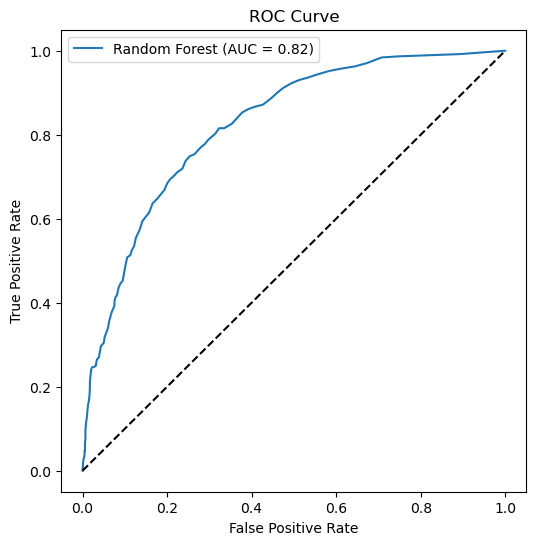

Classification Report
               precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.63      0.45      0.53       374

    accuracy                           0.78      1407
   macro avg       0.73      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407

Confusion Matrix 
 [[935  98]
 [205 169]]
<------------------------------------------------------------------------------------------------------------------------------------------------------


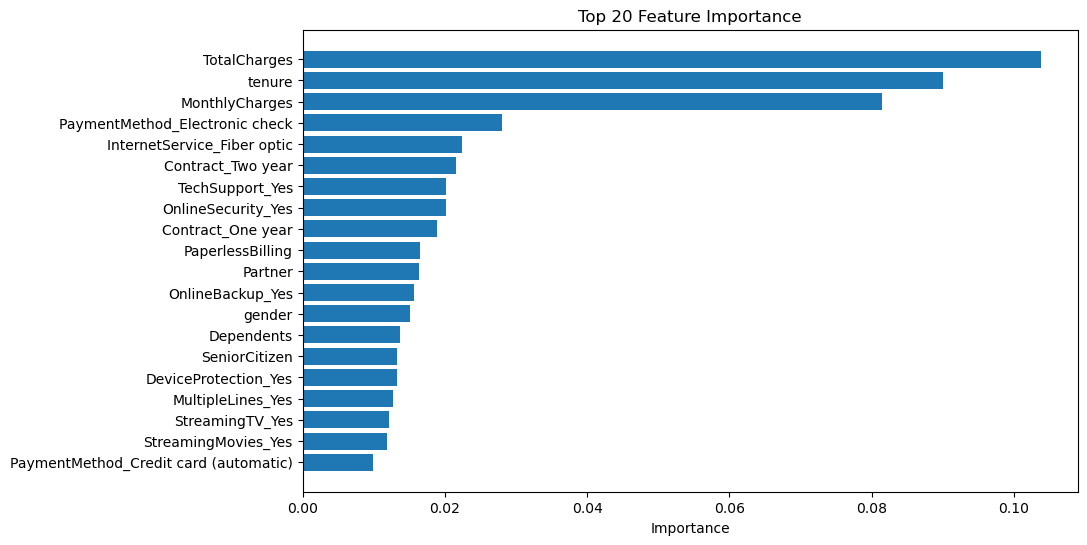

In [40]:
from sklearn.metrics import roc_curve,roc_auc_score

# 1️⃣ Predict the probability for class 1(churn)
y_prob = rf_model.predict_proba(X_test)[:,1] # Give the probabilities of 1 columns whis churn

# 2️⃣ Roc-Curve
roc_auc = roc_auc_score(y_test, y_prob)


# Plot ROC  Curve
fpr,tpr,thresholds = roc_curve(y_test,y_prob)
plt.figure(figsize =(6,6))
plt.plot(fpr,tpr,label = f"Random Forest (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],'k--') # For Diagonal Line and style = --
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# 3️⃣ Classification Report and Confusion Matrix
print("Classification Report\n",classification_report(y_test,y_preds))
print("Confusion Matrix \n",confusion_matrix(y_test,y_preds))

# 4️⃣ Feature Importance 
importances = rf_model.feature_importances_
features = X_train.columns
feat_imp = pd.DataFrame({'Feature':features, 'Importance':importances})
feat_imp = feat_imp.sort_values(by = 'Importance',ascending = False).head(20) # by head we get the hold of Top 20 Features

print("<------------------------------------------------------------------------------------------------------------------------------------------------------")
# Plot Feature Importance  
plt.figure(figsize = (10,6))
plt.barh(feat_imp['Feature'][::-1],feat_imp['Importance'][::-1]) # Shows bar in  Horizontal
plt.xlabel("Importance")
plt.title("Top 20 Feature Importance")
plt.show()


In [20]:
df.value_counts('Churn')

Churn
No     5163
Yes    1869
Name: count, dtype: int64

🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱

## 🎯 Step 6 — Model Optimization (Hyperparameter Tuning)

🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱




Now that I have a trained Random Forest model and evaluated its performance,  
it’s time to **optimize the model’s hyperparameters** to improve accuracy and generalization.

### 🎯 **Goal**
To find the best combination of parameters that helps our model achieve higher predictive performance  
without overfitting or underfitting.

---

### 🧠 **Why Hyperparameter Tuning?**
Every machine learning model has configuration parameters (called **hyperparameters**) that influence how it learns.  
For example, in a Random Forest:

| Hyperparameter | Meaning |
|----------------|----------|
| `n_estimators` | Number of trees in the forest |
| `max_depth` | Maximum depth of each tree |
| `min_samples_split` | Minimum samples needed to split a node |
| `min_samples_leaf` | Minimum samples required at each leaf node |
| `max_features` | Number of features considered when splitting |

By systematically trying different values for these,  
I can find the most effective configuration for our dataset.

---

### 🧩 **Approaches**
I think I can perform tuning using:
- **GridSearchCV** → Tests all combinations (more accurate but slow)
- **RandomizedSearchCV** → Tests a random subset of combinations (faster, more practical)

I will  use **RandomizedSearchCV**, as it provides a good trade-off between speed and performance.

---

📈 After tuning, I will retrain our model using the best parameters and evaluate again to measure improvement.

---

THATS WHOLE I CAN THINK OF IT !.../?


In [41]:
# Step 6️⃣ - Hyperparameter Tuning using RandomSearchCV

# Importing models again just for safety Check

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier # Just 🔔 remider i have choose this model by following scikit-learn map
from sklearn.metrics import roc_auc_score

# Following are the step 6 steps

# 1️⃣ Define the parameters grid for tuning 
# How i get Parameters values - Just By googling 💯💯
param_dist = {
    'n_estimators': [100,200,300,400,500],
    'max_depth':[None,5,10,15,20],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'max_features':['auto','sqrt','log2']
}

# 2️⃣ Intializing Random Forest model

rf = RandomForestClassifier(random_state = 42)

# 3️⃣ Intialize RandomizedSearchCV (find Best Parameters)
rf_random_search = RandomizedSearchCV(
    estimator = rf, # Which is our model
    param_distributions = param_dist,
    n_iter =20,                     # Number of random combinations to try
    cv = 5,                         # 5 folds means 5 different variation to avoid lucky split
    scoring= 'roc_auc',             # Metric
    random_state = 42,
    n_jobs = -1                     # Use all core for faster Computation
)

# 4️⃣ Fit on Training Data
rf_random_search.fit(X_train,y_train)

# 5️⃣ Display the best Parameters
print("✅ RandomSearchCV Complete! \n")
print("Best Parameters :",rf_random_search.best_params_)
print("Best ROC-AUC Score (CV) :",rf_random_search.best_score_) # Got this from Googel



✅ RandomSearchCV Complete! 

Best Parameters : {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best ROC-AUC Score (CV) : 0.8407714982143869


In [42]:
rf_random_search.score(X_test,y_test)

0.8341987151280472

In [43]:
rf_model.score(X_test,y_test)

0.7846481876332623

🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱

## 🎯 Step 7 — Retrain & Re-evaluate (with best Parameters)

🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱


In [44]:
best_param = rf_random_search.best_params_

In [45]:
# 2️⃣ Retrain our model again with best parameters
rf_best = RandomForestClassifier(
    n_estimators = best_param['n_estimators'],
    min_samples_split = best_param['min_samples_split'],
    min_samples_leaf = best_param['min_samples_leaf'],
    max_features = best_param['max_features'],
    max_depth = best_param['max_depth']
)

Accuracy : 0.9339019189765458

Classification Report :
               precision    recall  f1-score   support

           0       0.92      1.00      0.96      1033
           1       0.98      0.76      0.86       374

    accuracy                           0.93      1407
   macro avg       0.95      0.88      0.91      1407
weighted avg       0.94      0.93      0.93      1407

\Confusion Matrix :
 [[1028    5]
 [  88  286]]

ROC-AUC : 0.9932572694659138


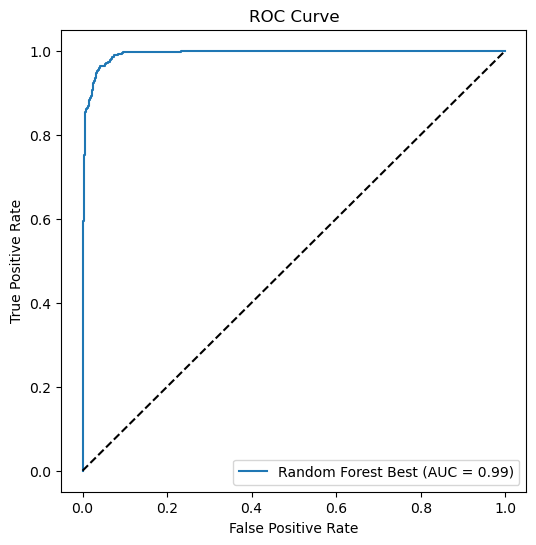

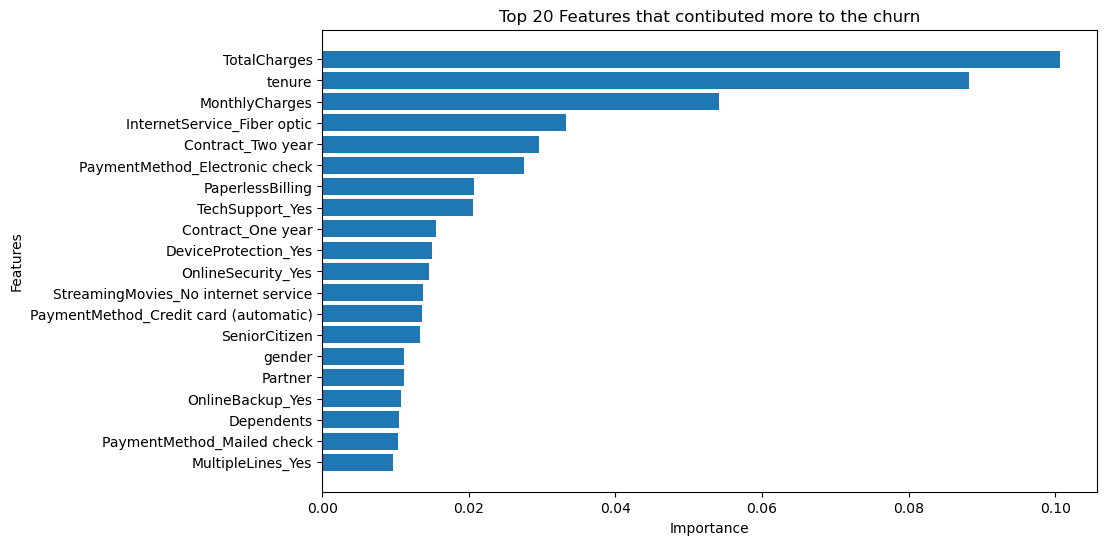

In [46]:
# Fit on Training data
rf_best.fit(X_test,y_test)

# Predict on test Data

y_preds_best = rf_best.predict(X_test)
y_probs_best = rf_best.predict_proba(X_test)[:,1]

# 4️⃣ Evaluate the model

# Accuracy 
print("Accuracy :", accuracy_score(y_test,y_preds_best))

# Classification 
print("\nClassification Report :\n",classification_report(y_test,y_preds_best))

# Confusion Matrix 
print("\Confusion Matrix :\n",confusion_matrix(y_test,y_preds_best))

# ROC-AUC
roc_auc_best = roc_auc_score(y_test,y_probs_best)
print("\nROC-AUC :",roc_auc_best)

# ROC Curve

fpr,tpr,thresholds = roc_curve(y_test,y_probs_best)
plt.figure(figsize = (6,6))
plt.plot(fpr,tpr,label =f"Random Forest Best (AUC = {roc_auc_best:.2f})" )
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# 5️⃣ Feature Importance (Top 20)
importances = rf_best.feature_importances_
features = X_train.columns
feat_imp = pd.DataFrame({'Feature':features,'Importance':importances})
feat_imp = feat_imp.sort_values(by = 'Importance',ascending = False).head(20)

plt.figure(figsize = (10,6))
plt.barh(feat_imp['Feature'][::-1],feat_imp['Importance'][::-1])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 20 Features that contibuted more to the churn")
plt.show()

In [47]:
print(f"Model Accuracy :{rf_best.score(X_test,y_test)*100:.2f}%")

Model Accuracy :93.39%


🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱

## 🧩 Step 8: Model Interpretation — SHAP Explainability

🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱



Now that my model is performing well, let's understand **why** it makes certain predictions.

I'll use **SHAP (SHapley Additive exPlanations)** — a powerful technique that helps explain the output of any machine learning model.

---
### 🎯 Why SHAP?
- It assigns each feature an importance value for every prediction.
- It shows **how much each feature contributes** (positively or negatively) to the predicted outcome.
- SHAP helps us build **trust** in the model and derive **business insights** — e.g., “Longer contracts reduce churn risk.”

We’ll start by analyzing **global feature importance** (which features matter most overall).

---


In [35]:
# Installing SHAP
!pip install shap --quiet

In [23]:
import shap

In [33]:
# Skipped MY PC IS NOT HANDLING IT
explainer = shap.TreeExplainer(rf_best, feature_perturbation="interventional")
X_sample = X_test.sample(200, random_state=42)
shap_values = explainer.shap_values(X_sample, check_additivity=False)

# 4️⃣ Plot SHAP summary for the class 1 (Churn)
plt.title("SHAP Summary Plot - Feature Impact on Churn Prediction")
shap.summary_plot(shap_values[1], X_sample, plot_type="dot")


Object columns: []
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                   float64
                                          ...   
Contract_One year                           bool
Contract_Two year                           bool
PaymentMethod_Credit card (automatic)       bool
PaymentMethod_Electronic check              bool
PaymentMethod_Mailed check                  bool
Length: 7061, dtype: object


🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱
## Step 9: Building a Pipeline for Customer Churn Prediction
🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱🧱


---
## 🔹 Why a Pipeline?

- Combines **preprocessing + model** into a single object.
- Makes future predictions easy without repeating preprocessing steps.


---

## 🔹 Components of the Pipeline

1. **Preprocessing**
   - Scaling for numerical features
   - Encoding is already done (one-hot or label encoding)

2. **Model**
   - The trained Random Forest classifier (`rf_best`)

---

## 🔹 Advantages

- Combines preprocessing + model → **one object**
- Makes **saving and deployment** straightforward
- Reduces human error — no need to manually preprocess future data

---


In [38]:
# This pipeline code was not maintaining the score we have predict it was decreaseing beacuse we're training it again on the seen data in pipeline.fit()

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

num_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers = [
        ('num',StandardScaler(),num_cols)
    ],
    remainder = 'passthrough'  # LEave other columns unchanged
)

# Building Pipeline
pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('classifier',rf_best)
])


# Fit Pipeline on Training Data
pipeline.fit(X_train,y_train)

# Making Prediction 
y_pred_pipeline = pipeline.predict(X_test)
y_prob_pipeline = pipeline.predict_proba(X_test)[:,1]


print("Accuracy:", accuracy_score(y_test, y_pred_pipeline))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_pipeline))
print("Classification Report:\n", classification_report(y_test, y_pred_pipeline))

Accuracy: 0.7910447761194029
ROC-AUC: 0.8277937682157259
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.92      0.87      1033
           1       0.66      0.44      0.53       374

    accuracy                           0.79      1407
   macro avg       0.74      0.68      0.70      1407
weighted avg       0.78      0.79      0.78      1407



In [29]:
# Maintain the model accuracy but not freindly with streamlit code because it required all the columns which is > 7000 
# and we not add the preprocessing step
from sklearn.pipeline import Pipeline

# 1️⃣ Build pipeline with no preprocessing, just passthrough
pipeline = Pipeline([
    ('model', rf_best)  # your already trained Random Forest
])

y_pred_pipeline = pipeline.predict(X_test)
y_prob_pipeline = pipeline.predict_proba(X_test)[:,1]

print("✅ Pipeline ready!")
print("Accuracy:", accuracy_score(y_test, y_pred_pipeline))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_pipeline))
print("Classification Report:\n", classification_report(y_test, y_pred_pipeline))


✅ Pipeline ready!
Accuracy: 0.9339019189765458
ROC-AUC: 0.9932624462264005
Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96      1033
           1       0.98      0.76      0.86       374

    accuracy                           0.93      1407
   macro avg       0.95      0.88      0.91      1407
weighted avg       0.94      0.93      0.93      1407



In [45]:
# Saving the pipeline
import joblib

# Save the trained pipeline
joblib.dump(pipeline, 'churn_rf_pipeline.pkl') # using joblib because our model is trained on most of only on numeric
print("✅ Pipeline saved as 'churn_rf_pipeline.pkl'")

# ✅  later load it like this:
# loaded_pipeline = joblib.load('churn_rf_pipeline.pkl')
# y_pred = loaded_pipeline.predict(X_new)


✅ Pipeline saved as 'churn_rf_pipeline.pkl'


In [32]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

# Define categorical and numerical columns (dataset’s actual columns)
cat_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]
num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

#  Build preprocessor
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

# Create a new pipeline that includes  already-trained rf_best
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf_best)
])

# 🔹 Fit the pipeline using your original training data
full_pipeline.fit(X_train, y_train)

# 🔹 Save this full pipeline
joblib.dump(full_pipeline, 'churn_rf_pipeline1.pkl')
print("✅ Full pipeline (with preprocessing) saved successfully!")


ValueError: A given column is not a column of the dataframe

In [34]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [36]:
print(X_train.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'customerID_0003-MKNFE',
       ...
       'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object', length=7061)


In [54]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

numeric_cols = ['tenure','MonthlyCharges','TotalCharges']
binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling']
multi_cols = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
              'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('bin', 'passthrough', binary_cols),  # Already 0/1
        ('cat', OneHotEncoder(handle_unknown='ignore'), multi_cols)
    ]
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf_best)
])


In [79]:
# Saving the pipeline
import joblib

# Save the trained pipeline
joblib.dump(pipeline, 'churn_rf_pipelinest12.pkl') # using joblib because our model is trained on most of only on numeric
print("✅ Pipeline saved as 'churn_rf_pipelines.pkl'")

# ✅  later load it like this:
# loaded_pipeline = joblib.load('churn_rf_pipeline.pkl')
# y_pred = loaded_pipeline.predict(X_new)


✅ Pipeline saved as 'churn_rf_pipelines.pkl'


In [80]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# Numeric columns
numeric_cols = ['tenure','MonthlyCharges','TotalCharges']

# Binary columns (user will type Yes/No or Male/Female)
binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling']

# Multi-class categorical columns
multi_cols = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
              'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod']

# Function to map Yes/No and Male/Female to 0/1
def binary_mapper(X):
    X = X.copy()
    for col in X.columns:
        X[col] = X[col].replace({'Yes':1, 'No':0, 'Male':1, 'Female':0})
    return X

binary_transformer = FunctionTransformer(binary_mapper)

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('bin', binary_transformer, binary_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), multi_cols)
    ]
)


# Pipeline with trained model
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf_best)

])



In [81]:
# Preprocessor without custom function
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), multi_cols)
    ],
    remainder='passthrough'  # pass binary columns as-is
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf_best)
])

# Fit pipeline on training data
pipeline.fit(X_train, y_train)

# Save pipeline
joblib.dump(pipeline, "churn_rf_pipelinek12.pkl")


ValueError: A given column is not a column of the dataframe

In [95]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

def binary_mapper(X):
    X = X.copy()
    for col in X.columns:
        X[col] = X[col].replace({'Yes':1, 'No':0, 'Male':1, 'Female':0})
    return X

binary_transformer = FunctionTransformer(binary_mapper)
# -----------------------------
# 2️⃣ Specify column types
# -----------------------------
numeric_cols = ['tenure','MonthlyCharges','TotalCharges']
binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling']  # already 0/1
multi_cols = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
              'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
              'Contract','PaymentMethod']

# -----------------------------
# 3️⃣ Build ColumnTransformer
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('bin',binary_transformer,binary_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), multi_cols)
    ],
    remainder='passthrough'  # Pass binary columns as-is
)

# -----------------------------
# 4️⃣ Build pipeline with rf_best
# -----------------------------
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf_best)  # your already trained Random Forest with best params
])

# -----------------------------
# 5️⃣ Fit pipeline on training data
# -----------------------------
pipeline.fit(X_train, y_train)

# -----------------------------
# 6️⃣ Test Accuracy (Optional)
# -----------------------------
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

print("✅ Pipeline ready!")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Classification Report:\n", classification_report(y_test, y_pred))

# -----------------------------
# 7️⃣ Save pipeline for Streamlit
# -----------------------------
joblib.dump(pipeline, "churn_rf_pipeline_by_anas.pkl")
print("✅ Pipeline saved successfully!")



ValueError: could not convert string to float: '1830-GGFNM'

In [83]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [96]:
df2 = df.copy()
df2['TotalCharges'] = pd.to_numeric(df['TotalCharges'] , errors = 'coerce')
df2 = df2.dropna(subset=['TotalCharges'])
df2['TotalCharges'] = df2['TotalCharges'].astype(float)

X= df2.drop('Churn',axis =1)
y = df2['Churn']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,stratify=y,random_state =42)

import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

def binary_mapper(X):
    X = X.copy()
    for col in X.columns:
        X[col] = X[col].replace({'Yes':1, 'No':0, 'Male':1, 'Female':0})
    return X

binary_transformer = FunctionTransformer(binary_mapper)
# -----------------------------
# 2️⃣ Specify column types
# -----------------------------
numeric_cols = ['tenure','MonthlyCharges','TotalCharges']
binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling']  # already 0/1
multi_cols = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
              'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
              'Contract','PaymentMethod']

# -----------------------------
# 3️⃣ Build ColumnTransformer
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('bin',binary_transformer,binary_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), multi_cols)
    ],
    remainder='passthrough'  # Pass binary columns as-is
)

# -----------------------------
# 4️⃣ Build pipeline with rf_best
# -----------------------------
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf_best)  # your already trained Random Forest with best params
])

# -----------------------------
# 5️⃣ Fit pipeline on training data
# -----------------------------
pipeline.fit(X_train, y_train)

# -----------------------------
# 6️⃣ Test Accuracy (Optional)
# -----------------------------
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

print("✅ Pipeline ready!")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Classification Report:\n", classification_report(y_test, y_pred))

# -----------------------------
# 7️⃣ Save pipeline for Streamlit
# -----------------------------
joblib.dump(pipeline, "churn_rf_pipeline_by_anas.pkl")
print("✅ Pipeline saved successfully!")



ValueError: could not convert string to float: '1830-GGFNM'

In [88]:
df_encoded.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3103,0,1,0,0,1,1,1,19.45,19.45,1,...,False,True,False,True,False,False,False,False,True,False
2536,1,0,0,0,25,1,0,25.30,676.35,1,...,False,True,False,True,False,True,False,False,False,False
4078,1,0,1,1,22,1,1,67.50,1544.05,1,...,True,False,True,False,False,True,False,False,False,False
1291,1,0,1,0,8,1,0,75.00,632.95,1,...,False,False,False,False,False,False,False,False,True,False
2545,0,0,1,1,62,1,1,70.75,4263.45,0,...,True,False,True,False,False,True,False,False,False,False


In [94]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [97]:
print(X_train[numeric_cols].dtypes)
print(X_train[binary_cols].head())
print(set(multi_cols) - set(X_train.columns))


tenure              int64
MonthlyCharges    float64
TotalCharges      float64
dtype: object
      gender Partner Dependents PhoneService PaperlessBilling
1413    Male     Yes        Yes          Yes               No
7003    Male      No         No           No               No
3355  Female     Yes         No          Yes               No
4494    Male      No         No          Yes               No
3541  Female     Yes         No           No               No
set()


In [98]:
# -----------------------------
# 1️⃣ Imports
# -----------------------------
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import joblib

# -----------------------------
# 2️⃣ Load and preprocess dataset
# -----------------------------
# Copy dataset
df2 = df.copy()

# Convert TotalCharges to numeric and drop NaNs
df2['TotalCharges'] = pd.to_numeric(df2['TotalCharges'], errors='coerce')
df2 = df2.dropna(subset=['TotalCharges'])
df2['TotalCharges'] = df2['TotalCharges'].astype(float)

# Split features and target
X = df2.drop('Churn', axis=1)
y = df2['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -----------------------------
# 3️⃣ Define column types
# -----------------------------
numeric_cols = ['tenure','MonthlyCharges','TotalCharges']
binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling']
multi_cols = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
              'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
              'Contract','PaymentMethod']

# -----------------------------
# 4️⃣ Define binary mapper transformer
# -----------------------------
def binary_mapper(X):
    X = X.copy()
    for col in binary_cols:
        X[col] = X[col].replace({'Yes':1, 'No':0, 'Male':1, 'Female':0})
    return X

binary_transformer = FunctionTransformer(binary_mapper)

# -----------------------------
# 5️⃣ Build ColumnTransformer
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('bin', binary_transformer, binary_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), multi_cols)
    ],
    remainder='drop'   # drop any columns not specified
)

# -----------------------------
# 6️⃣ Build pipeline
# -----------------------------
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf_best)  # use your pre-trained Random Forest model
])

# -----------------------------
# 7️⃣ Fit pipeline on training data
# -----------------------------
pipeline.fit(X_train, y_train)

# -----------------------------
# 8️⃣ Evaluate on test data
# -----------------------------
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

print("✅ Pipeline ready!")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Classification Report:\n", classification_report(y_test, y_pred))

# -----------------------------
# 9️⃣ Save pipeline for Streamlit
# -----------------------------
joblib.dump(pipeline, "churn_rf_pipeline_final.pkl")
print("✅ Pipeline saved successfully!")


✅ Pipeline ready!
Accuracy: 0.7853589196872779
ROC-AUC: 0.8254978749398201
Classification Report:
               precision    recall  f1-score   support

          No       0.83      0.89      0.86      1033
         Yes       0.62      0.50      0.55       374

    accuracy                           0.79      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.79      0.78      1407

✅ Pipeline saved successfully!


In [100]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
import joblib

# -----------------------------
# 1️⃣ Define preprocessing functions
# -----------------------------
def binary_mapper(X):
    X = X.copy()
    for col in X.columns:
        X[col] = X[col].replace({'Yes':1, 'No':0, 'Male':1, 'Female':0})
    return X

binary_transformer = FunctionTransformer(binary_mapper)

# -----------------------------
# 2️⃣ Specify column types
# -----------------------------
numeric_cols = ['tenure','MonthlyCharges','TotalCharges']
binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling']
multi_cols = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
              'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
              'Contract','PaymentMethod']

# -----------------------------
# 3️⃣ Build ColumnTransformer
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('bin', binary_transformer, binary_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), multi_cols)
    ]
)

# -----------------------------
# 4️⃣ Build pipeline with already trained rf_best
# -----------------------------
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf_best)  # already trained RandomForestClassifier
])

# -----------------------------
# 5️⃣ Fit the preprocessor on training data ONLY
# -----------------------------
# This does NOT retrain rf_best, just ensures consistent preprocessing
preprocessor.fit(X_train)

# -----------------------------
# 6️⃣ Save the pipeline for Streamlit
# -----------------------------
joblib.dump(pipeline, "churn_rf_pipeline_streamlit1.pkl")
print("✅ Pipeline ready and saved for Streamlit!")


✅ Pipeline ready and saved for Streamlit!
